In [9]:
import urllib
import pandas as pd
# import seaborn as sns
import matplotlib.pyplot as plt
# import matplotlib.ticker as mtick
import json
import networkx as nx

In [8]:
with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/edges/all_party_edges.csv") as response:
    df_party_edges = pd.read_csv(response)

with urllib.request.urlopen(f"https://raw.githubusercontent.com/Somon8/social_graphs_25/main/final-project/party_colors.json") as response:
    party_colors = json.load(response)
from folketingsperioder import periods_df  #Use this to show which government

df_party_edges.head()

,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Danmarksdemokraterne,Danmarksdemokraterne,65,386,382.0,0.989637,finans_budget
1,Danmarksdemokraterne,Dansk Folkeparti,65,6220,6182.0,0.993891,finans_budget
2,Danmarksdemokraterne,Det Konservative Folkeparti,65,3613,3585.0,0.992250,finans_budget
3,Danmarksdemokraterne,Enhedslisten,65,93,40.0,0.430108,finans_budget
4,Danmarksdemokraterne,Inuit Ataqatigiit,65,30,3.0,0.100000,finans_budget


In [11]:
traditional_parties = ["Det Konservative Folkeparti", "Enhedslisten", "Liberal Alliance", "Radikale Venstre", "Socialdemokratiet", "Socialistisk Folkeparti", "Venstre", "Dansk Folkeparti"]
# parties_to_drop_momentarily = ['Kirsteligt Folkeparti', "Not able to assign", Ny Alliance]
mask_only_traditional_parties = (df_party_edges['source'].isin(traditional_parties)) & (df_party_edges['target'].isin(traditional_parties))
df_traditional = df_party_edges[mask_only_traditional_parties]

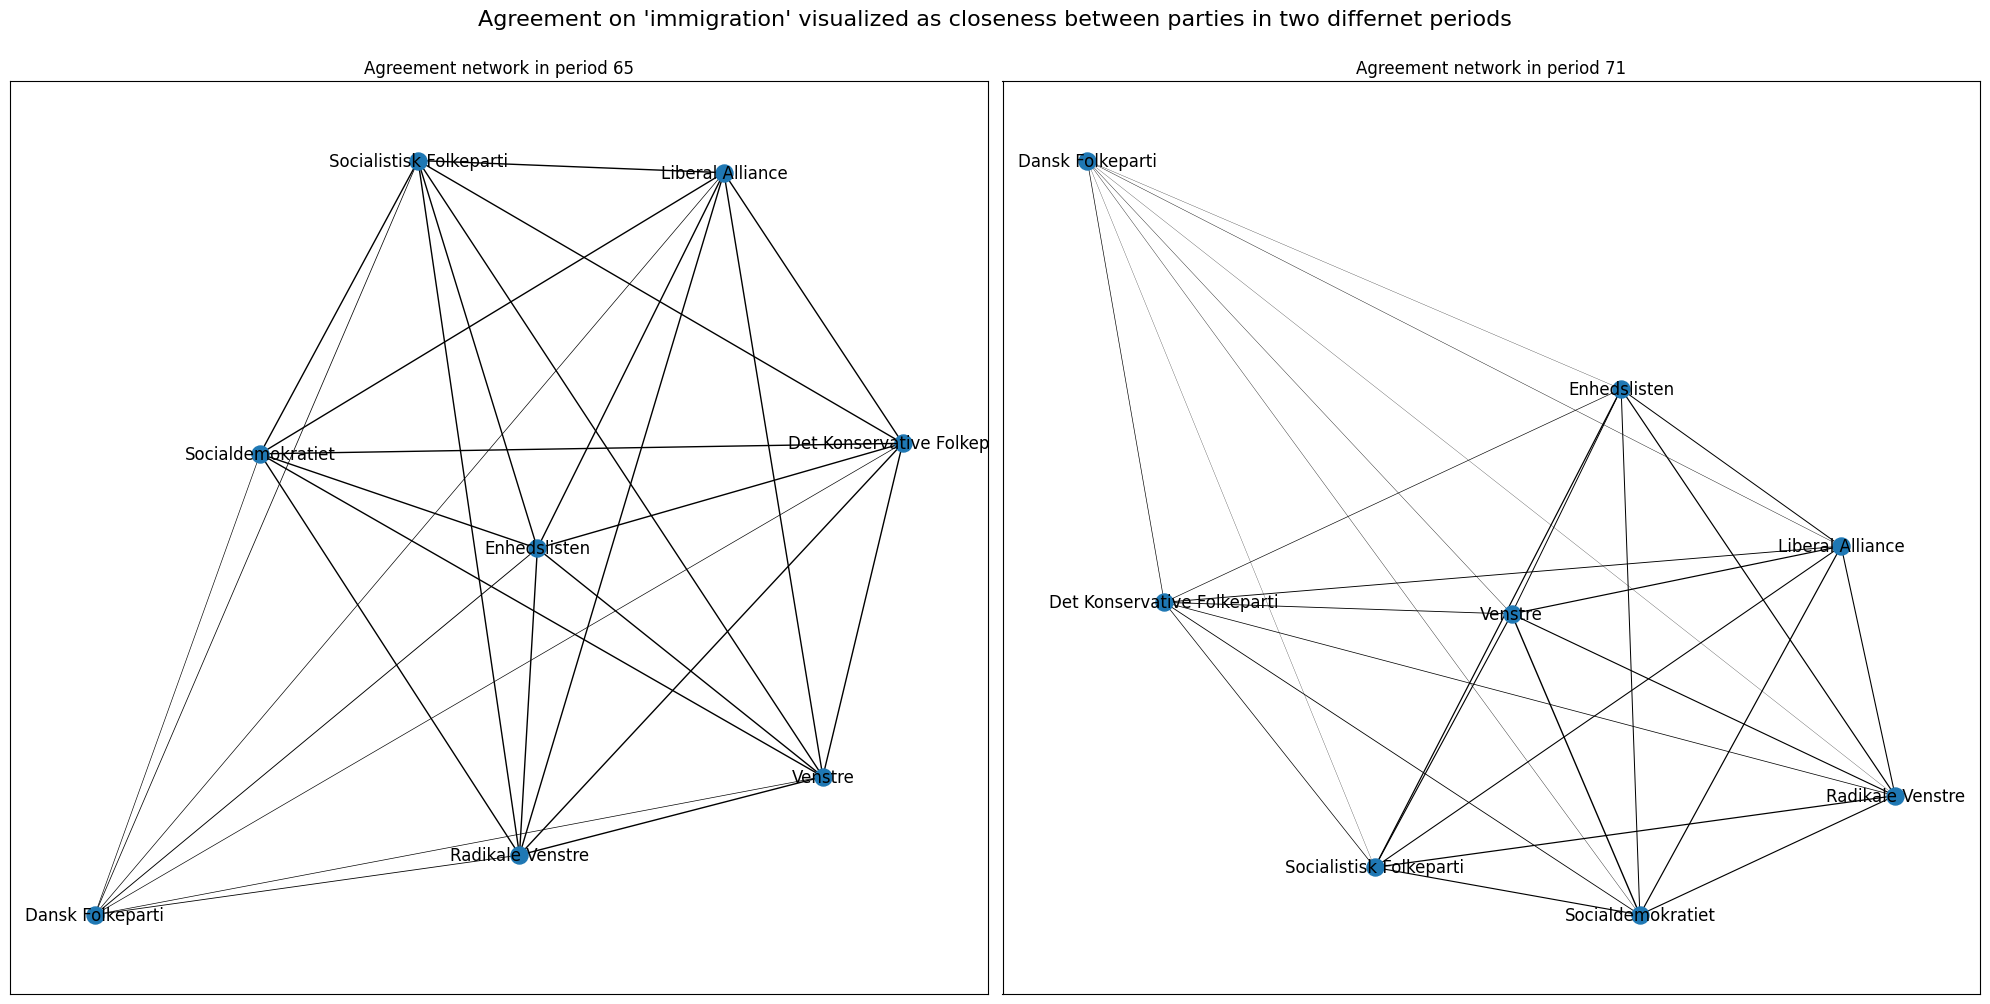

In [ ]:
#Here we can potentially do some limiting etc. of the edgelist so we only get what's relevant
topic = "immigration"
df_topic = df_traditional[df_traditional["topic"] == topic]

period_1 = 65
period_2 = 71
df_p1 = df_topic[df_topic["Period"] == period_1]
df_p2 = df_topic[df_topic["Period"] == period_2]

figure, axs = plt.subplots(1, 2, figsize=(20, 10))  # 2 rows, 1 column


G1 = nx.from_pandas_edgelist(df = df_p1, source = "source", target= "target", edge_attr="weight", create_using=nx.Graph)
G2 = nx.from_pandas_edgelist(df = df_p2, source = "source", target= "target", edge_attr="weight", create_using=nx.Graph)

G1.remove_edges_from(nx.selfloop_edges(G1))
G2.remove_edges_from(nx.selfloop_edges(G2))


edge_weights_1 = [weight for (u,v), weight in nx.get_edge_attributes(G1, 'weight').items()]
edge_weights_2 = [weight for (u,v), weight in nx.get_edge_attributes(G2, 'weight').items()]


# plot_colors_1 = []
# for party in df_masked["target"].unique():
#     try:
#         party_color = party_colors[party]
#     except:
#         party_color = party_colors["Andre"] #Set it to grey
#     plot_colors.append(party_color)

pos_1 = nx.forceatlas2_layout(G1, seed = 42, weight = "weight", max_iter = 5000)
pos_2 = nx.forceatlas2_layout(G2, seed = 42, weight = "weight", max_iter = 5000)

#Draw nodes
nx.draw_networkx_nodes(G1, pos_1, node_size=150, ax =axs[0]) #, ax = axs, node_color = [politician_colors[node] for node in G.nodes()]
nx.draw_networkx_nodes(G2, pos_2, node_size=150, ax =axs[1])

#Draw edges
nx.draw_networkx_edges(G1, pos_1, width = edge_weights_1, ax = axs[0])
nx.draw_networkx_edges(G2, pos_2, width = edge_weights_2, ax = axs[1])

#Draw node labels
nx.draw_networkx_labels(G1, pos_1, font_size = 12, ax = axs[0])
nx.draw_networkx_labels(G2, pos_2, font_size = 12, ax = axs[1]) 

#Set title
axs[0].set_title(f"Agreement network in period {period_1}")
axs[1].set_title(f"Agreement network in period {period_2}")

plt.suptitle(f"Agreement on '{topic}' visualized as closeness between parties in two differnet periods", fontsize = 16, y = 1)

plt.tight_layout()
plt.show()





In [ ]:

# def edgelist_and_graph_to_visualization(edgelist, G, df):
#     figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height


#     # Some arguments for the visualization
#     period = df['Period'].unique() #We should maybe convert this to a time-period instea
#     topic = df['topics_simple'].unique()


#     #NETWULF FOR DRAWING GRAPHS could be interesting. Danny has worked with it before
#     pos = nx.forceatlas2_layout(G
#                                             , seed = 42
#                                             , weight = "weight"
#                                             , max_iter = 5000
#                                             )

#     # nodes
#     agreement_threshold = 0.7
#     df_draw = g_df[g_df['weight'] > agreement_threshold]

#     print(len(g_df), len(df_draw))

#     #Get the edges and widths to draw
#     edges = list(zip(df_draw['source'], df_draw['target']))
#     edge_widths = df_draw['weight'].tolist()


#     nx.draw_networkx_nodes(G, pos, node_size=200, ax = axs, node_color = [politician_colors[node] for node in G.nodes()])

#     # edges
#     nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 1 for w in edge_widths], alpha = 0.1, ax = axs)


#     # node labels
#     nx.draw_networkx_labels(G, pos, font_size=10, ax = axs)

#     # Build legend: only parties that appear in politician_colors
#     used_colors = set(politician_colors.values())

#     legend_handles = []
#     for party, color in party_colors.items():
#         if color in used_colors:
#             legend_handles.append(Patch(facecolor=color, edgecolor='black', label=party))

#     axs.legend(handles=legend_handles, title="Party", loc="upper left", bbox_to_anchor=(1, 1))



#     # ax.margins(0.08)
#     plt.axis("off")
#     plt.tight_layout()
#     plt.suptitle(f"Politician agreement network, colored by party, for period {period[0]}, only showing edges with more than {agreement_threshold*100:.0f}% agreement, for topic {topic[0]}", fontsize = 14)
#     # plt.title(f"Topic is {topic[0]}")

#     plt.show()

# edgelist_and_graph_to_visualization(g_df, G, df = df_cleaned)
